In [97]:
import operator
from typing import Annotated, List, TypedDict, Literal
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AnyMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [98]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [99]:
class StateCOT(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]
    plan : str
    result : str = []
    approvel : bool = False


In [100]:
def planner_node(state:StateCOT) -> StateCOT:
    question = state["messages"][-1].content
    
    prompt = f"""
        kamu adalah seorang planner untuk pertanyaan, kamu harus memecahkan pertanyaan menjadi langkah langkah kecil seperti plan bertahap dari awal sampai akhir,
        JANGAN BERIKAN JAWABAN AKHIR
        misalkan pertanyaan seperti ini:
        "ada sebuah truk dari kota A yang ingin ke kota c tapi truck tersebut harus melewati kota b dulu
        
        Plan:
            1. Truck pergi ke kota B
            2. lalu truck pergi ke kota C
            3. Truck kembali ke kota B
            4. lalu pulang ke kota A
        
        pertanyaan:
        {question}
    """ 
    model = ChatGroq(model_name="openai/gpt-oss-120b",  streaming=True)
    plan_output = model.invoke(prompt)
    return {"plan" : plan_output.content }

In [116]:
def generation(state:StateCOT) -> StateCOT:
    question = state["messages"][-1].content
    plan = state["plan"]
    
    prompt = f"""
        kamu adalah pelaksana dari plan yang diberikan, kamu harus mengeksekusi secara bertahap dan sesuai dengan plan yang diberikan
        
        plan:
        {plan}
        
        question:
        {question}
    """
    model = ChatGroq(model_name="openai/gpt-oss-120b",  streaming=True)
    plan_output = model.invoke(prompt)
    
    print(plan_output.content)
    print("=" * 50)
    return {"result" : plan_output.content}
    

In [112]:
def human_approval(state: StateCOT) -> Literal["generation", "__end__", "planner"]:
    plan = state.get("plan", "Tidak ada plan")
    print(f"\n--- RENCANA PLANNER ---\n{plan}\n")
    
    approval = input("Lanjut ke generation? (ya/tidak/ulang): ").lower()
    
    print("=" * 50)
    if approval == "ya":
        print("---PLAN DISETUJUI====")
        return "generation"  # Lanjut eksekusi
    elif approval == "ulang":
        print("---PLAN DIULANG====")
        return "planner"     # Suruh planner mikir lagi (Loop)
    else:
        print("---PLAN TIDAK ADA====")
        return "__end__"     # Berhenti

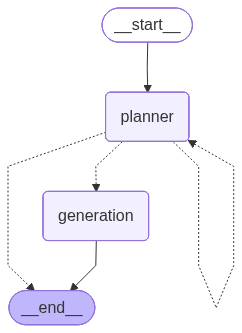

In [ ]:
workflow = StateGraph(StateCOT)

workflow.add_node("planner", planner_node)
workflow.add_node("generation", generation)

workflow.add_edge(START, "planner")

workflow.add_conditional_edges(
    "planner",         
    human_approval,     
    {
        "generation": "generation",
        "planner": "planner",
        "__end__": END
    }
)

workflow.add_edge("generation", END)

memory = MemorySaver()
builder = workflow.compile(checkpointer=memory)
builder



In [119]:
query = """Saya perlu menjadwalkan rapat tim berdurasi 1 jam yang bisa dihadiri oleh Andi, Budi, dan Cici.

Andi ada kelas dari jam 08.00 sampai 10.00, dan jam makan siang 12.00-13.00.

Budi baru sampai kantor jam 09.30 dan pulang jam 15.00.

Cici harus menjemput anaknya tepat jam 14.30 (jadi rapat harus sudah selesai sebelumnya).

Di antara jam 08.00 sampai 16.00, jam berapa saja rapat bisa dimulai?"""

state = {"messages": query}
result = builder.invoke(state, config= {"configurable" : {"thread_id": 1}})



--- RENCANA PLANNER ---
**Rencana Penyelesaian (Tanpa Menyebutkan Jawaban Akhir)**  

1. **Kumpulkan semua informasi waktu yang tersedia dan tidak tersedia**  
   - *Andi*  
     - Tidak tersedia: 08.00‑10.00 (kelas)  
     - Tidak tersedia: 12.00‑13.00 (makan siang)  
   - *Budi*  
     - Tidak tersedia: sebelum 09.30 (belum sampai)  
     - Tidak tersedia: setelah 15.00 (pulang)  
   - *Cici*  
     - Tidak tersedia: setelah 14.30 (harus menjemput anak)  

2. **Buat rentang kerja yang dibatasi**  
   - Seluruh rentang yang dipertimbangkan: 08.00‑16.00.  
   - Tandai setiap menit (atau setiap 5‑menit) dalam rentang ini sebagai “tersedia” atau “tidak tersedia” untuk masing‑masing orang.

3. **Konversi tiap jadwal menjadi interval “bebas”**  
   - Untuk setiap orang, tuliskan interval‑interval di mana mereka **bisa** hadir (bukan yang terblokir).  
   - Contohnya, untuk Andi: 10.00‑12.00 dan 13.00‑16.00 (asumsi tidak ada batas lain).  
   - Lakukan hal yang sama untuk Budi dan Cici.

4

In [120]:
print(result["plan"])

**Rencana Penyelesaian Masalah Penjadwalan Rapat 1 jam**

1. **Kumpulkan Informasi Ketersediaan Tiap Orang**  
   - **Andi**:  
     - Tidak tersedia 08.00‑10.00 (kelas)  
     - Tidak tersedia 12.00‑13.00 (jam makan siang)  
   - **Budi**:  
     - Tidak tersedia sebelum 09.30 (baru sampai kantor)  
     - Tidak tersedia setelah 15.00 (pulang)  
   - **Cici**:  
     - Tidak tersedia setelah 14.30 (harus menjemput anak)  

2. **Buat Rentang Waktu Kerja Umum**  
   - Interval utama yang dipertimbangkan: 08.00‑16.00  

3. **Ubah Setiap Jadwal Menjadi *Slot* Waktu yang *Bebas***  
   - Untuk tiap orang, bagi rentang kerja menjadi blok‑blok yang tidak terhalang oleh kegiatan mereka.  
   - Contoh:  
     - Andi → blok bebas: 10.00‑12.00, 13.00‑16.00  
     - Budi → blok bebas: 09.30‑15.00  
     - Cici → blok bebas: 08.00‑14.30  

4. **Identifikasi *Intersection* (irisan) Antara Semua Blok Bebas**  
   - Ambil irisan dari ketiga set blok bebas untuk menemukan rentang waktu di mana **semua

In [121]:
print(result["result"])

**Langkah‑langkah sesuai rencana**

1. **Ketersediaan tiap orang**  
   - **Andi** – bebas: **10.00‑12.00**, **13.00‑16.00**  
   - **Budi** – bebas: **09.30‑15.00**  
   - **Cici** – bebas: **08.00‑14.30**

2. **Irisan (intersection) semua blok bebas**  

| Andi ↔ Budi | Hasil irisan |
|------------|--------------|
| 10.00‑12.00 ↔ 09.30‑15.00 | **10.00‑12.00** |
| 13.00‑16.00 ↔ 09.30‑15.00 | **13.00‑15.00** |

Sekarang iriskan hasil di atas dengan blok Cici (08.00‑14.30):

| Hasil sebelumnya ↔ Cici | Irisan akhir |
|------------------------|--------------|
| 10.00‑12.00 ↔ 08.00‑14.30 | **10.00‑12.00** |
| 13.00‑15.00 ↔ 08.00‑14.30 | **13.00‑14.30** |

Jadi interval waktu **di mana ketiga orang sekaligus tersedia** adalah:

- **10.00‑12.00**
- **13.00‑14.30**

3. **Pertimbangkan durasi rapat (1 jam)**  

- Interval **10.00‑12.00** memiliki panjang 2 jam → titik mulai yang memungkinkan: dari **10.00** sampai **11.00** (karena 11.00 + 1 jam = 12.00).  
- Interval **13.00‑14.30** memiliki

In [115]:
query = """Saya perlu menjadwalkan rapat tim berdurasi 1 jam yang bisa dihadiri oleh Andi, Budi, dan Cici.

Andi ada kelas dari jam 08.00 sampai 10.00, dan jam makan siang 12.00-13.00.

Budi baru sampai kantor jam 09.30 dan pulang jam 15.00.

Cici harus menjemput anaknya tepat jam 14.30 (jadi rapat harus sudah selesai sebelumnya).

Di antara jam 08.00 sampai 16.00, jam berapa saja rapat bisa dimulai?"""

state = {"messages": query}
result = builder.invoke(state, config= {"configurable" : {"thread_id": 1}})



--- RENCANA PLANNER ---
**Rencana Penyelesaian : Menentukan Semua Jam Mulai yang Mungkin untuk Rapat 1 Jam (08.00‑16.00)**  

1. **Catat Jadwal “Tidak Tersedia” Tiap Orang**  
   - *Andi* : 08.00‑10.00 (kelas) → tidak tersedia.  
               12.00‑13.00 (jam makan siang) → tidak tersedia.  
   - *Budi* : 09.30‑15.00 (di kantor) → tersedia hanya sebelum 09.30 dan setelah 15.00.  
   - *Cici* : 14.30‑… (menjemput anak) → rapat harus selesai **sebelum** 14.30.  

2. **Ubah Jadwal “Tidak Tersedia” menjadi “Tersedia” untuk Tiap Orang**  
   - Tentukan rentang kerja keseluruhan: 08.00‑16.00.  
   - Untuk masing‑masing, kurangi interval “tidak tersedia” dari rentang kerja, sehingga didapatkan satu atau lebih interval “tersedia”.  
   - Contoh:  
     - Andi → tersedia: 10.00‑12.00 dan 13.00‑16.00.  
     - Budi → tersedia: 08.00‑09.30 dan 15.00‑16.00.  
     - Cici → tersedia: 08.00‑14.30 (asumsikan tidak ada “tidak tersedia” lain).  

3. **Gabungkan Semua Interval “Tersedia” Menjadi Satu